# Stage 3 — DFC, one dataset per cohort

Windowed connectivity: one row per window, twelve QC columns, and the edges —
stored one column per edge below ~20,000 of them and as a packed
`fixed_size_list<float32>` above.

Same four steps as `01_activation.ipynb`:

1. **inventory** the `(atlas, window_s, cohort)` grid that actually exists;
2. **load QC first** — twelve columns, a few MB per cohort, on any atlas —
   because that is what tells you which windows are worth loading edges for;
3. **edges**, both storage modes, per subject on a fine atlas and pooled on a
   coarse one;
4. **join** participants, QC and phenotype.

The edge columns are the memory cliff in this project, so nothing here
materialises them without pricing the read first.

### Running it

```bash
module load apptainer/1.4.5
salloc --account=rpp-aevans-ab --cpus-per-task=4 --mem=32G --time=3:00:00

export FMRIDECOMP_SIF=/project/6008063/tamires/singularity/fmri_decomp.sif
cd /project/6008063/tamires/DecomposingfMRI
apptainer exec --bind /project,/scratch,/home --pwd $PWD $FMRIDECOMP_SIF \
    jupyter lab --no-browser --ip=0.0.0.0 --port=8888
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as pads

sys.path.insert(0, str(Path.cwd()))
import nbtools as nb

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib absent -- plots are skipped, tables still print")

ATLAS_COARSE = "yeo7"            # 21 edges: a whole cohort of edges is cheap
ATLAS_FINE = "harvardoxford"     # 6,105 edges: per subject, or QC only
WINDOW_S = 60                    # one aperture, present in every cohort's grid

ROOT = nb.output_root()
print("output_root:", ROOT)

output_root: /project/6008063/tamires/DecomposingfMRI/outputs


## 1. Which `(atlas, window_s, cohort)` cells exist

`window_s` sits between `atlas` and `cohort` in the path, so "one atlas, one
window size, every cohort" is a single directory — the pooled read. The grid is
deliberately not full: `windows.by_size` restricts the 15 s aperture to the
coarse atlases, because a correlation over *p* nodes is singular unless
`n − 1 ≥ p` and a 15 s window is 10 samples at TR = 1.49.

In [2]:
inv = nb.inventory("dfc")
print(f"{len(inv)} dfc shard(s)")
nb.inventory_summary(inv, "dfc").head(20)

12964 dfc shard(s)


,cohort,atlas,window_s,n_shards,n_subs,n_tasks
0,camcan,harvardoxford,30.0,647,647,1
1,camcan,harvardoxford,60.0,647,647,1
2,camcan,harvardoxford,120.0,647,647,1
3,camcan,harvardoxford,300.0,647,647,1
4,camcan,networks,30.0,647,647,1
5,camcan,networks,60.0,647,647,1
6,camcan,networks,120.0,647,647,1
7,camcan,networks,300.0,647,647,1
8,camcan,yeo7,30.0,647,647,1
9,camcan,yeo7,60.0,647,647,1


In [3]:
# The grid, as shards. A zero is a pair that was never run -- check it against
# `windows.sizes_s` and `windows.by_size` in the config before calling it a gap.
inv.assign(window_s=inv["window_s"].astype(float)).pivot_table(
    index=["cohort", "atlas"], columns="window_s", values="path",
    aggfunc="size", fill_value=0)

window_s                      15.0   30.0   60.0   120.0  300.0
cohort         atlas                                           
camcan         harvardoxford      0    647    647    647    647
               networks           0    647    647    647    647
               yeo7               0    647    647    647    647
camcan_ccfrail harvardoxford      0     53     53     53     53
               networks           0     53     53     53     53
               yeo7               0     53     53     53     53
cneuromod      harvardoxford      0    240    240    240    240
               networks         240    240    240    240    240
               yeo7             240    240    240    240    240
ds002837       harvardoxford      0     86     86     86     86
               networks          86     86     86     86     86
               yeo7              86     86     86     86     86

In [4]:
# Configured vs. present, per cohort. `configured` is `windows.sizes_s`; a size
# that is configured but absent for one atlas only is the by_size restriction,
# not a failure.
cfg = nb.cohort_configs().set_index("cohort")
rows = []
for cohort in sorted(inv["cohort"].unique()):
    sub = inv[inv["cohort"] == cohort]
    configured = {float(w) for w in str(cfg.loc[cohort, "window_sizes_s"]).split(",") if w}
    present = {float(w) for w in sub["window_s"].unique()}
    rows.append({"cohort": cohort,
                 "configured": sorted(configured),
                 "present": sorted(present),
                 "absent": sorted(configured - present),
                 "atlases": sorted(sub["atlas"].unique())})
pd.DataFrame(rows)

,cohort,configured,present,absent,atlases
0,camcan,"[30.0, 60.0, 120.0, 300.0]","[30.0, 60.0, 120.0, 300.0]",[],"[harvardoxford, networks, yeo7]"
1,camcan_ccfrail,"[30.0, 60.0, 120.0, 300.0]","[30.0, 60.0, 120.0, 300.0]",[],"[harvardoxford, networks, yeo7]"
2,cneuromod,"[15.0, 30.0, 60.0, 120.0, 300.0]","[15.0, 30.0, 60.0, 120.0, 300.0]",[],"[harvardoxford, networks, yeo7]"
3,ds002837,"[15.0, 30.0, 60.0, 120.0, 300.0]","[15.0, 30.0, 60.0, 120.0, 300.0]",[],"[harvardoxford, networks, yeo7]"


### The rank floor is arithmetic, not a preference

A window is `round(window_s / tr)` samples; a correlation matrix over *p* nodes
is singular unless `n − 1 ≥ p`. So the shortest usable window is a property of
the atlas and the TR:

```
min_window_s = (n_nodes + 0.5) * tr
```

The pipeline computes edges below that floor anyway and flags the rows
`rank_deficient` (`rank_policy: warn`) rather than dropping them — so the
correct number of rank-deficient windows is *predictable*, and a disagreement
between prediction and data is worth chasing.

In [5]:
n_nodes = {a: len(nb.atlas_labels(a)) for a in sorted(inv["atlas"].unique())}
print("nodes per atlas:", n_nodes)

grid = []
for cohort in sorted(inv["cohort"].unique()):
    tr = float(cfg.loc[cohort, "tr"])
    for atlas, p in n_nodes.items():
        floor_s = (p + 0.5) * tr
        for w in sorted({float(x) for x in
                         inv.loc[(inv["cohort"] == cohort) & (inv["atlas"] == atlas),
                                 "window_s"]}):
            grid.append({"cohort": cohort, "tr": tr, "atlas": atlas, "n_nodes": p,
                         "window_s": w, "n_samples": int(round(w / tr)),
                         "min_window_s": round(floor_s, 1),
                         "expect_rank_deficient": w < floor_s})
grid = pd.DataFrame(grid)
grid[grid["expect_rank_deficient"]].sort_values(["cohort", "atlas", "window_s"])

nodes per atlas: {'harvardoxford': 111, 'networks': 14, 'yeo7': 7}


,cohort,tr,atlas,n_nodes,window_s,n_samples,min_window_s,expect_rank_deficient
0,camcan,2.47,harvardoxford,111,30.0,12,275.4,True
1,camcan,2.47,harvardoxford,111,60.0,24,275.4,True
2,camcan,2.47,harvardoxford,111,120.0,49,275.4,True
4,camcan,2.47,networks,14,30.0,12,35.8,True
12,camcan_ccfrail,1.12,harvardoxford,111,30.0,27,124.9,True
13,camcan_ccfrail,1.12,harvardoxford,111,60.0,54,124.9,True
14,camcan_ccfrail,1.12,harvardoxford,111,120.0,107,124.9,True
24,cneuromod,1.49,harvardoxford,111,30.0,20,166.1,True
25,cneuromod,1.49,harvardoxford,111,60.0,40,166.1,True
26,cneuromod,1.49,harvardoxford,111,120.0,81,166.1,True


## 2. QC first

Twelve columns. Parquet is columnar, so this physically reads twelve column
chunks per file and skips the edges entirely — the same read costs the same
whether the atlas has 21 edges or 6,105. This is always the first read.

In [6]:
qc_ds, _ = nb.dataset("dfc", ATLAS_FINE)
filt = pads.field("window_s") == str(WINDOW_S)
gb_qc, n_frag = nb.estimate_gb(qc_ds, columns=list(nb.DFC_QC_COLUMNS), filter=filt)
gb_all, _ = nb.estimate_gb(qc_ds, filter=filt)
print(f"{ATLAS_FINE} @ {WINDOW_S}s, all cohorts: {n_frag} shard(s)")
print(f"  QC columns only  {gb_qc * 1000:9.2f} MB")
print(f"  every column     {gb_all * 1000:9.2f} MB   <- the edges")

harvardoxford @ 60s, all cohorts: 1026 shard(s)
  QC columns only       1.69 MB
  every column       1486.40 MB   <- the edges


In [7]:
qc = nb.load_dfc(ATLAS_FINE, window_s=WINDOW_S)
print(f"{len(qc):,} windows, {round(nb.mem_mb(qc), 1)} MB in memory")
qc.head()

85,493 windows, 45.3 MB in memory


,window_id,start_tr,start_s,stimulus_start_s,stimulus_end_s,n_tr_nominal,n_tr_available,n_tr_effective,frac_good_frames,crosses_run_boundary,crosses_clip_boundary,rank_deficient,ses,run,acq,run_key,window_s,cohort,task,sub,atlas
0,0,0,0.000000,0.0,60.0,24,25,25,1.0,False,False,True,None,None,None,cohort-camcan_sub-CC110033_task-Movie,60,camcan,Movie,CC110033,harvardoxford
1,1,5,12.350000,12.0,72.0,24,25,25,1.0,False,False,True,None,None,None,cohort-camcan_sub-CC110033_task-Movie,60,camcan,Movie,CC110033,harvardoxford
2,2,10,24.700001,24.0,84.0,24,25,25,1.0,False,False,True,None,None,None,cohort-camcan_sub-CC110033_task-Movie,60,camcan,Movie,CC110033,harvardoxford
3,3,15,37.049999,36.0,96.0,24,24,24,1.0,False,False,True,None,None,None,cohort-camcan_sub-CC110033_task-Movie,60,camcan,Movie,CC110033,harvardoxford
4,4,20,49.400002,48.0,108.0,24,24,24,1.0,False,False,True,None,None,None,cohort-camcan_sub-CC110033_task-Movie,60,camcan,Movie,CC110033,harvardoxford


In [8]:
# The reliability picture, per cohort. `n_tr_effective` is the column that
# matters: pairwise deletion means two subjects contribute different frame
# counts to the same nominal window.
qc.groupby("cohort").agg(
    windows=("window_id", "size"),
    subs=("sub", "nunique"),
    n_tr_nominal=("n_tr_nominal", "median"),
    n_tr_effective_median=("n_tr_effective", "median"),
    n_tr_effective_min=("n_tr_effective", "min"),
    frac_good=("frac_good_frames", "mean"),
    rank_deficient=("rank_deficient", "mean"),
    crosses_run=("crosses_run_boundary", "mean"),
    crosses_clip=("crosses_clip_boundary", "mean"),
).round(3)

,windows,subs,n_tr_nominal,n_tr_effective_median,n_tr_effective_min,frac_good,rank_deficient,crosses_run,crosses_clip
cohort,,,,,,,,,
camcan,22494,647,24.0,24.0,2,0.923,1.0,0.0,0.0
camcan_ccfrail,1837,53,54.0,40.0,2,0.685,1.0,0.0,0.0
cneuromod,13370,5,40.0,40.0,6,0.974,1.0,0.0,0.0
ds002837,47792,86,60.0,60.0,60,1.000,1.0,0.0,0.0


In [9]:
# Predicted vs. observed rank deficiency at this aperture. A row where the
# prediction says False and the data says >0 means frames were censored down
# past the floor -- which is exactly what heavy motion does.
observed = (qc.groupby("cohort")["rank_deficient"].mean().rename("observed").reset_index())
predicted = grid[(grid["atlas"] == ATLAS_FINE) & (grid["window_s"] == WINDOW_S)][
    ["cohort", "tr", "n_samples", "min_window_s", "expect_rank_deficient"]]
predicted.merge(observed, on="cohort").round(3)

,cohort,tr,n_samples,min_window_s,expect_rank_deficient,observed
0,camcan,2.47,24,275.4,True,1.0
1,camcan_ccfrail,1.12,54,124.9,True,1.0
2,cneuromod,1.49,40,166.1,True,1.0
3,ds002837,1.00,60,111.5,True,1.0


### The same window is not the same measurement in two cohorts

Fisher-z of a correlation over *n* samples has sampling SD `1 / sqrt(n − 3)`.
`n` is `n_tr_effective`, and that depends on the TR and on how many frames
survived censoring — so a 60 s window is a *noisier* estimate in Cam-CAN CC700
(TR 2.47) than in ccfrail (TR 1.12), by roughly the square root of the ratio.

This runs in the same direction as the healthy-vs-frail contrast those two
cohorts are meant to support: more measurement noise in CC700 inflates its
edge variance, which makes the **frail** group look **less variable** than it
is. Censoring makes it worse, not better — ccfrail loses the most frames from
exactly the participants the study is about. The column that lets a model
account for it is `n_tr_effective`, which is why it travels with every row.

In [10]:
eff = qc.groupby("cohort")["n_tr_effective"].median().rename("n_tr_effective")
noise = pd.concat([cfg["tr"], eff], axis=1).dropna()
noise["nominal_samples"] = (WINDOW_S / noise["tr"]).round().astype(int)
noise["fisher_z_sd"] = 1 / np.sqrt(noise["n_tr_effective"] - 3)
noise["sd_relative_to_best"] = noise["fisher_z_sd"] / noise["fisher_z_sd"].min()
noise.round(3).sort_values("fisher_z_sd")

,tr,n_tr_effective,nominal_samples,fisher_z_sd,sd_relative_to_best
cohort,,,,,
ds002837,1.00,60.0,60,0.132,1.000
camcan_ccfrail,1.12,40.0,54,0.164,1.241
cneuromod,1.49,40.0,40,0.164,1.241
camcan,2.47,24.0,24,0.218,1.648


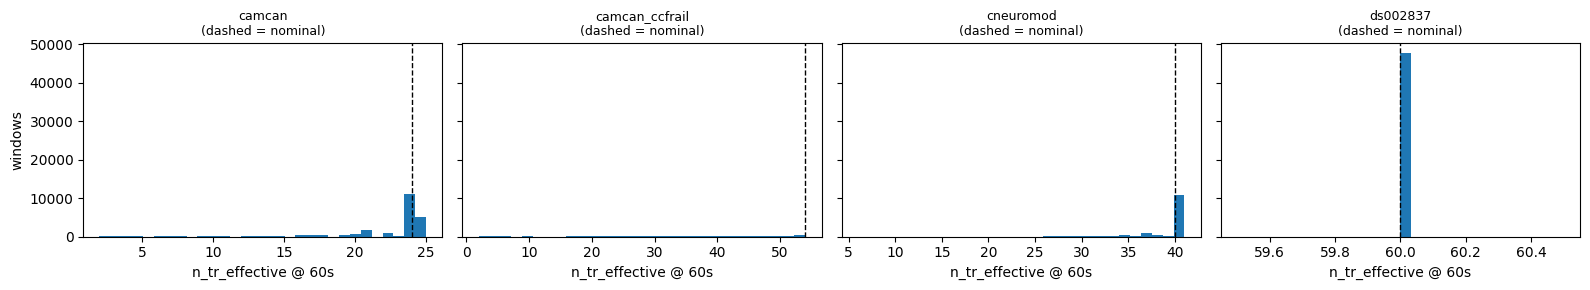

In [11]:
if HAVE_MPL:
    cohorts = sorted(qc["cohort"].unique())
    fig, ax = plt.subplots(1, len(cohorts), figsize=(4 * len(cohorts), 3), sharey=True)
    for a, cohort in zip(np.atleast_1d(ax), cohorts):
        sel = qc[qc["cohort"] == cohort]
        a.hist(sel["n_tr_effective"], bins=30)
        a.axvline(sel["n_tr_nominal"].median(), color="k", ls="--", lw=1)
        a.set_title(f"{cohort}\n(dashed = nominal)", fontsize=9)
        a.set_xlabel(f"n_tr_effective @ {WINDOW_S}s")
    np.atleast_1d(ax)[0].set_ylabel("windows")
    fig.tight_layout()

## 3. Edges

Two storage modes, and which one a file uses is a property of the atlas, not of
the cohort: one column per edge named `NodeA__NodeB` below ~20,000 edges, a
packed `fixed_size_list<float32>` in a single `edges` column above it.
`nb.read_subject_edges` (which wraps `dfc.read_edges`) returns the same
`(n_windows, n_edges)` array either way — never branch on the mode yourself.

Edge order is the canonical upper triangle (row-major, `k=1`) of the atlas
label table, and `nb.edge_names` rebuilds it from
`outputs/meta/atlas-<a>_labels.csv`. Read the names from there rather than from
`get_atlas(...)`: the label table is what the data was written against, and it
needs neither nilearn nor network access.

In [12]:
for atlas, p in n_nodes.items():
    ds, _ = nb.dataset("dfc", atlas)
    cols = nb.edge_columns(ds)
    mode = "list (packed)" if cols == ["edges"] else "columns"
    print(f"{atlas:>15}  {p:>4} nodes  {p * (p - 1) // 2:>6} edges  ->  {mode}")

  harvardoxford   111 nodes    6105 edges  ->  columns
       networks    14 nodes      91 edges  ->  columns
           yeo7     7 nodes      21 edges  ->  columns


In [13]:
# One subject on the fine atlas. Per shard is how edges get touched at 6,105
# columns without materialising a cohort of them.
shards = nb.subject_shards(ATLAS_FINE, WINDOW_S)
print(f"{len(shards)} shard(s) at {ATLAS_FINE} @ {WINDOW_S}s")
qc_one, edges, names = nb.read_subject_edges(shards["path"].iloc[0])
print(f"{shards['cohort'].iloc[0]} / sub-{shards['sub'].iloc[0]}: "
      f"edges {edges.shape}, {edges.nbytes / 1e6:.1f} MB")
print("first edges:", names[:3])
print("NaN edges:", f"{np.isnan(edges).mean():.3%}")

1026 shard(s) at harvardoxford @ 60s
camcan / sub-CC110033: edges (35, 6105), 0.9 MB
first edges: ['Left_Frontal_Pole__Right_Frontal_Pole', 'Left_Frontal_Pole__Left_Insular_Cortex', 'Left_Frontal_Pole__Right_Insular_Cortex']
NaN edges: 0.000%


reconstructed matrix: (111, 111) symmetric: True


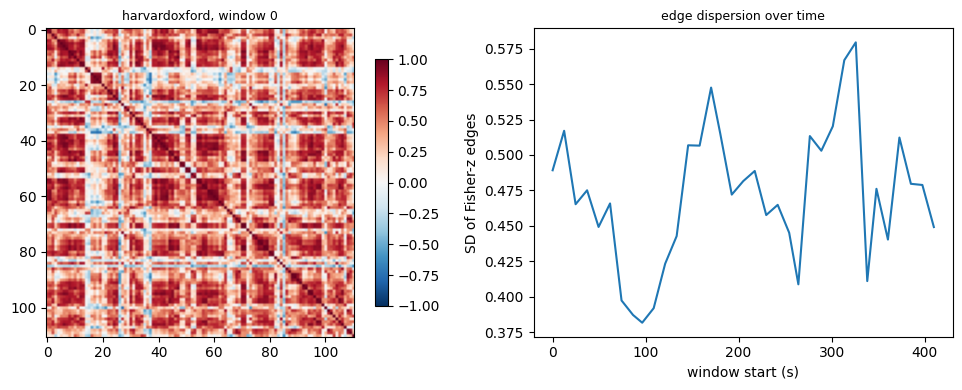

In [14]:
# Edges are raw r (`fisher_z_applied: false` in the schema metadata), so the
# transform is never already done for you.
z = nb.fisher_z(edges)
window_0 = nb.full_matrix_from_upper(edges[0], len(nb.atlas_labels(ATLAS_FINE)))
print("reconstructed matrix:", window_0.shape,
      "symmetric:", np.allclose(window_0, window_0.T, equal_nan=True))

if HAVE_MPL:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    im = ax[0].imshow(window_0, vmin=-1, vmax=1, cmap="RdBu_r")
    ax[0].set_title(f"{ATLAS_FINE}, window 0", fontsize=9)
    fig.colorbar(im, ax=ax[0], shrink=0.8)
    ax[1].plot(qc_one["start_s"], np.nanstd(z, axis=1))
    ax[1].set_xlabel("window start (s)"); ax[1].set_ylabel("SD of Fisher-z edges")
    ax[1].set_title("edge dispersion over time", fontsize=9)
    fig.tight_layout()

In [15]:
# A whole cohort of edges, on the coarse atlas where that is affordable.
# guard_gb refuses a read it prices above the guard; the message says how to
# narrow it. Try it first on the fine atlas to see the guard fire.
target = sorted(inv["cohort"].unique())[0]
fine_ds, _ = nb.dataset("dfc", ATLAS_FINE)
fine_filt = ((pads.field("window_s") == str(WINDOW_S)) & (pads.field("cohort") == target))
est, n_frag = nb.estimate_gb(fine_ds, filter=fine_filt)
print(f"{target} @ {ATLAS_FINE} {WINDOW_S}s with edges: {est * 1000:.1f} MB "
      f"across {n_frag} shard(s)")
try:
    nb.load_dfc(ATLAS_FINE, window_s=WINDOW_S, cohort=target,
                with_edges=True, guard_gb=est / 2)
except MemoryError as exc:
    print("\nguard fired, as intended:\n ", exc)

camcan @ harvardoxford 60s with edges: 937.3 MB across 647 shard(s)

guard fired, as intended:
  this read is estimated at 937.3 MB uncompressed across 647 shard(s), over the 468.7 MB guard.
  Narrow it (cohort=, task=, sub=, a coarser atlas, one window_s), drop the edge/parcel columns, or pass guard_gb=None to override deliberately.


In [16]:
dfc = nb.load_dfc(ATLAS_COARSE, window_s=WINDOW_S, cohort=target, with_edges=True)
edge_cols = [c for c in dfc.columns if "__" in c]
print(f"{target} @ {ATLAS_COARSE} {WINDOW_S}s: {dfc.shape}, "
      f"{round(nb.mem_mb(dfc), 1)} MB, {len(edge_cols)} edge columns")
dfc[["window_id", "start_s", "n_tr_effective", "rank_deficient"] + edge_cols[:3]].head()

camcan @ yeo7 60s: (22494, 42), 13.3 MB, 21 edge columns


,window_id,start_s,n_tr_effective,rank_deficient,Visual__Somatomotor,Visual__DorsalAttention,Visual__VentralAttention
0,0,0.000000,25,False,0.857663,0.759905,0.841510
1,1,12.350000,25,False,0.475046,0.849238,0.769828
2,2,24.700001,25,False,-0.129880,0.770162,0.432865
3,3,37.049999,24,False,-0.310887,0.770127,0.358865
4,4,49.400002,24,False,-0.207948,0.790978,0.341079


## 4. Who these windows belong to

Same three-file join as stage 2 — curation, pipeline QC, phenotype — reduced to
one row per subject so it can carry a per-subject DFC summary.

`config/phenotype/*_phenotype.csv` does not exist yet: age, sex and the frailty
scores are in no file this pipeline reads or writes, and have to be imported
from each dataset's own source table with `tools/make_phenotype.py`. Until they
are, `has_pheno` is False everywhere and any age- or sex-stratified cell below
will be empty rather than wrong.

`has_scores` marks Cam-CAN's behavioural battery, consolidated from the
archive's `cc700-scored/` summaries by
`preprocessing/camcan/03_build_participants_scores.py`. It covers `camcan` and
not `camcan_ccfrail`.

In [17]:
COHORTS = sorted(inv["cohort"].unique())
subjects = pd.concat([nb.subject_table(c) for c in COHORTS], ignore_index=True)
print(subjects.groupby("cohort")[["has_pheno", "has_scores"]].agg(["size", "sum"])
      .iloc[:, [0, 1, 3]]
      .set_axis(["subject_rows", "with_phenotype", "with_scores"], axis=1))

no phenotype for cohort='camcan' at config/phenotype/camcan_phenotype.csv
  Build it: python tools/make_phenotype.py --help (sources listed in config/phenotype/README.md)


/project/6008063/tamires/DecomposingfMRI/notebooks/nbtools.py:558: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["has_scores"] = out["has_scores"].fillna(False)


no phenotype for cohort='camcan_ccfrail' at config/phenotype/camcan_ccfrail_phenotype.csv
  Build it: python tools/make_phenotype.py --help (sources listed in config/phenotype/README.md)
no phenotype for cohort='cneuromod' at config/phenotype/cneuromod_phenotype.csv
  Build it: python tools/make_phenotype.py --help (sources listed in config/phenotype/README.md)
no phenotype for cohort='ds002837' at config/phenotype/ds002837_phenotype.csv
  Build it: python tools/make_phenotype.py --help (sources listed in config/phenotype/README.md)
                subject_rows  with_phenotype  with_scores
cohort                                                   
camcan                   648               0          646
camcan_ccfrail            55               0            0
cneuromod                288               0            0
ds002837                  86               0            0


In [18]:
# Per-subject DFC summary at one aperture: dispersion of Fisher-z edges over
# windows, which is the simplest thing "dynamic" can mean, plus the reliability
# columns needed to interpret it.
per_sub = (qc.groupby(["cohort", "task", "sub"])
             .agg(n_windows=("window_id", "size"),
                  n_tr_effective_median=("n_tr_effective", "median"),
                  frac_good_frames_dfc=("frac_good_frames", "mean"),
                  frac_rank_deficient=("rank_deficient", "mean"))
             .reset_index())
per_sub["fisher_z_sd_expected"] = 1 / np.sqrt(per_sub["n_tr_effective_median"] - 3)

analysis = subjects.merge(per_sub, on=["cohort", "task", "sub"], how="right")
print(f"{len(analysis)} subject x task row(s) with stage-3 data at "
      f"{ATLAS_FINE} @ {WINDOW_S}s")
analysis.head()

1026 subject x task row(s) with stage-3 data at harvardoxford @ 60s


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


,participant_id,sub,cohort,task,excluded,exclusion_reason,mean_fd,median_fd,max_fd,frac_fd_gt_0p2,frac_fd_gt_0p5,n_fd_frames,n_motion_runs,best_lag_tr,peak_isc,n_isc_subjects,frac_stimulus_covered,stimulus_duration_s,n_tr_total,frac_good_frames,n_tr_good,frac_parcels_empty,n_parcels,n_parcels_empty,qc_atlas,fd_source,fd_columns,qc_note,n_tests_with_data,CardioMeasures_RAinit,...,Synsem_pValid_semunamb,Synsem_pTimeout_semunamb,Synsem_pAnticipation_semunamb,Synsem_pYes_semunacc,Synsem_pNo_semunacc,Synsem_RTvalid_semunacc,Synsem_RTyes_semunacc,Synsem_RTno_semunacc,Synsem_reITRTvalid_semunacc,Synsem_reITRTyes_semunacc,Synsem_reITRTno_semunacc,Synsem_pValid_semunacc,Synsem_pTimeout_semunacc,Synsem_pAnticipation_semunacc,TOT_sum_KC,TOT_sum_KI,TOT_sum_TO,TOT_sum_DK,TOT_sum_SE,TOT_sum_NU,TOT_ToT_ratio,TOT_ErrorMessages,has_scores,has_pheno,end_movie,n_windows,n_tr_effective_median,frac_good_frames_dfc,frac_rank_deficient,fisher_z_sd_expected
0,sub-CC110033,CC110033,camcan,Movie,False,NaN,0.084087,0.073315,0.305603,0.031250,0.000000,192.0,1.0,0.0,0.449750,648.0,1.0,476.70999,193.0,1.000000,193.0,0.0,111.0,0.0,harvardoxford,sub-CC110033_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,8.0,NaN,...,1.0,0.0,0.0,0.04762,0.95238,1582.286,2280.000,1547.400,1457.810,2280.0000,1431.991,1.00000,0.00000,0.0,12.0,2.0,7.0,29.0,0.0,0.0,0.36842,NaN,True,False,NaN,35,24.0,1.000000,1.0,0.218218
1,sub-CC110037,CC110037,camcan,Movie,False,NaN,0.367336,0.096163,5.462255,0.260417,0.130208,192.0,1.0,0.0,0.551731,648.0,1.0,476.70999,193.0,0.777202,150.0,0.0,111.0,0.0,harvardoxford,sub-CC110037_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,7.0,NaN,...,1.0,0.0,0.0,0.57895,0.42105,2172.632,2303.364,1992.875,2006.421,2166.3420,1821.530,0.90476,0.09524,0.0,34.0,3.0,5.0,7.0,0.0,1.0,0.12821,NaN,True,False,NaN,35,21.0,0.788048,1.0,0.235702
2,sub-CC110045,CC110045,camcan,Movie,False,NaN,0.052359,0.046730,0.427705,0.010417,0.000000,192.0,1.0,0.0,0.594554,648.0,1.0,476.70999,193.0,1.000000,193.0,0.0,111.0,0.0,harvardoxford,sub-CC110045_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,9.0,NaN,...,1.0,0.0,0.0,0.15000,0.85000,2194.850,3180.667,2020.882,1848.755,3115.9810,1724.958,0.95238,0.04762,0.0,18.0,5.0,9.0,18.0,0.0,0.0,0.33333,NaN,True,False,NaN,35,24.0,1.000000,1.0,0.218218
3,sub-CC110056,CC110056,camcan,Movie,False,NaN,0.670139,0.256170,10.969075,0.588542,0.338542,192.0,1.0,0.0,0.379138,648.0,1.0,476.70999,193.0,0.476684,92.0,0.0,111.0,0.0,harvardoxford,sub-CC110056_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,8.0,NaN,...,1.0,0.0,0.0,0.09524,0.90476,1392.429,1729.000,1357.000,1312.311,1710.2610,1280.937,1.00000,0.00000,0.0,34.0,3.0,10.0,3.0,0.0,0.0,0.22727,NaN,True,False,NaN,31,11.0,0.512581,1.0,0.353553
4,sub-CC110069,CC110069,camcan,Movie,False,NaN,0.091389,0.049462,1.029831,0.083333,0.026042,192.0,1.0,1.0,0.400524,648.0,1.0,476.70999,193.0,0.932642,180.0,0.0,111.0,0.0,harvardoxford,sub-CC110069_task-Movie_desc-confounds_timeser...,"'framewise_displacement', as computed upstream",NaN,8.0,NaN,...,1.0,0.0,0.0,0.23810,0.76190,1078.667,976.600,1110.562,1026.999,926.5033,1063.032,1.00000,0.00000,0.0,4.0,7.0,0.0,38.0,1.0,0.0,0.00000,NaN,True,False,NaN,35,22.0,0.930571,1.0,0.229416


In [19]:
# What a group comparison would be resting on, before any model. Read the
# rightmost two columns together: they are the acquisition confound, and they
# are not equal across the two Cam-CAN cohorts.
cols = [c for c in ["mean_fd", "frac_good_frames", "frac_good_frames_dfc",
                    "frac_rank_deficient", "n_tr_effective_median",
                    "fisher_z_sd_expected"]
        if c in analysis.columns]
analysis.groupby("cohort")[cols].median().round(3)

,mean_fd,frac_good_frames,frac_good_frames_dfc,frac_rank_deficient,n_tr_effective_median,fisher_z_sd_expected
cohort,,,,,,
camcan,0.127,0.979,0.982,1.0,24.0,0.218
camcan_ccfrail,0.320,0.647,0.663,1.0,35.0,0.177
cneuromod,0.120,0.989,0.988,1.0,40.0,0.164
ds002837,0.107,1.000,1.000,1.0,60.0,0.132


## Where this stops

No exclusion applied, no Fisher-z group average, no model. Three things to
carry into whatever comes next:

* **`n_tr_effective`, not `n_tr_nominal`.** Windows differ in how much data
  they actually saw, and the Fisher-z sampling SD is `1/sqrt(n − 3)`.
* **`rank_deficient` rows are computed and flagged, not dropped.** Deciding
  what to do with them is an analysis decision; the pipeline deliberately does
  not make it.
* **`camcan` vs `camcan_ccfrail` is confounded by acquisition.** TR 2.47 vs
  1.12, five echoes vs one — the noise difference points the same way as the
  hypothesis. `config/camcan_ccfrail_movie.yaml`'s header comments have the
  full comparison; read them before running the contrast.

Memory, if you widen any of this:

* QC-only reads are flat in the atlas size — start there, always;
* one dataset object per atlas, and filter on `window_s` / `cohort` / `task` /
  `sub` so directories are pruned before a file opens;
* on `harvardoxford`, edges are per shard via `nb.read_subject_edges`; a pooled
  read with `with_edges=True` at 30 s is 1–2.5 GB for one cohort and grows with
  `1/stride`;
* price it with `nb.estimate_gb(...)` first, and leave `guard_gb` on;
* a full-cohort pass belongs in a batch job that writes a summary table, not in
  this notebook.